<a href="https://colab.research.google.com/github/masum-mir/machine-learning-journey/blob/main/missing_value_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Per_Column_Predictive_Imputation


## 0 · Setup

In [27]:
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception: pass
import os
DATA='/content/drive/MyDrive/DHMAINetRG/dataset/diabetes_dataset_missing_value.csv'
FIGDIR="figures"; os.makedirs(FIGDIR,exist_ok=True)

import numpy as np, pandas as pd, warnings, time
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":300,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":.25,"font.size":10})


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install catboost

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression, BayesianRidge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
  precision_recall_curve, confusion_matrix)

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [29]:
df = pd.read_csv(DATA)
NUM = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
CATc = ["gender", "smoking_history"]
BIN = ["hypertension", "heart_disease"]
CAT = CATc + BIN
CATEGORICAL = set(CAT)
TARGET = "diabetes"

enc = df.copy()
maps = {}
for col in CATc:
    cats = sorted(df[col].dropna().unique())
    maps[col] = {cls: i for i, cls in enumerate(cats)}
    enc[col] = enc[col].map(maps[col])

def encode(frame):
    E = frame.copy()
    for c in CATc:
        E[c] = E[c].map(maps[c])
    return E.astype(float)
FEATURES = NUM + CATc + BIN
print("shape:", df.shape, "| complete rows:", df.dropna().shape[0])
print("missing per column (raw):")
print(df.isna().sum())


shape: (1487, 9) | complete rows: 450
missing per column (raw):
gender                  64
age                    126
hypertension           149
heart_disease          249
smoking_history        161
bmi                    144
HbA1c_level            220
blood_glucose_level    185
diabetes                 0
dtype: int64


## 1 · Missingness overview

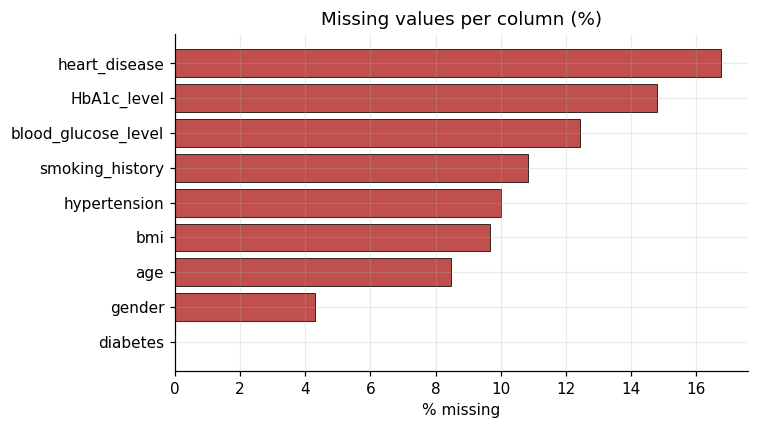

In [30]:
miss = df.isna().sum()
pct = (miss / len(df) * 100).round(2)

m = pct.sort_values()

fig, ax = plt.subplots(figsize=(7,4))

ax.barh(
    m.index,
    m.values,
    color="#C0504D",
    edgecolor="black",
    lw=0.5
)

ax.set_title("Missing values per column (%)")
ax.set_xlabel("% missing")

plt.tight_layout()
fig.savefig(f"{FIGDIR}/01_missing_percentage.png",bbox_inches="tight", format="png")
plt.show()

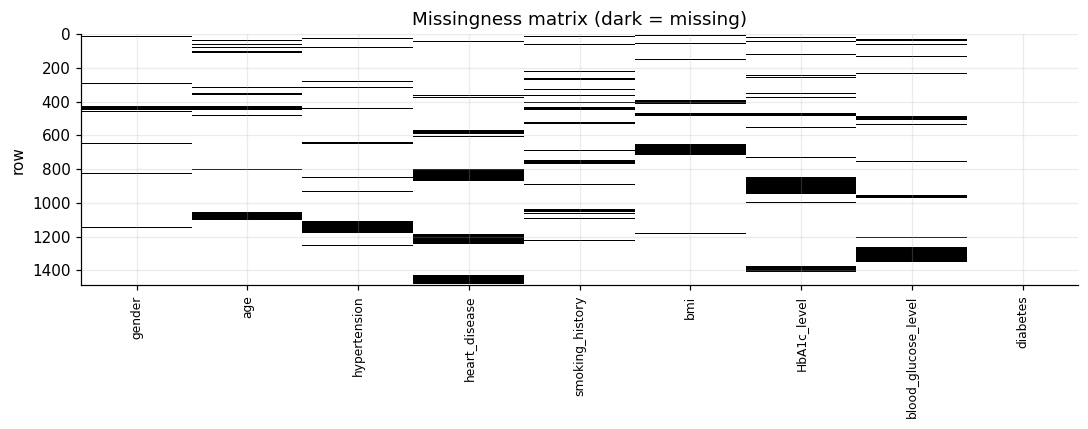

In [31]:
fig, ax = plt.subplots(figsize=(10,4))

ax.imshow(
    df.isna().values,
    aspect="auto",
    cmap="Greys",
    interpolation="none"
)

ax.set_title("Missingness matrix (dark = missing)")
ax.set_ylabel("row")

ax.set_xticks(range(df.shape[1]))
ax.set_xticklabels(df.columns, rotation=90, fontsize=8)

plt.tight_layout()
fig.savefig(f"{FIGDIR}/02_missing_matrix.png",bbox_inches="tight", format="png")
plt.show()

## 2 · Pre-imputation EDA

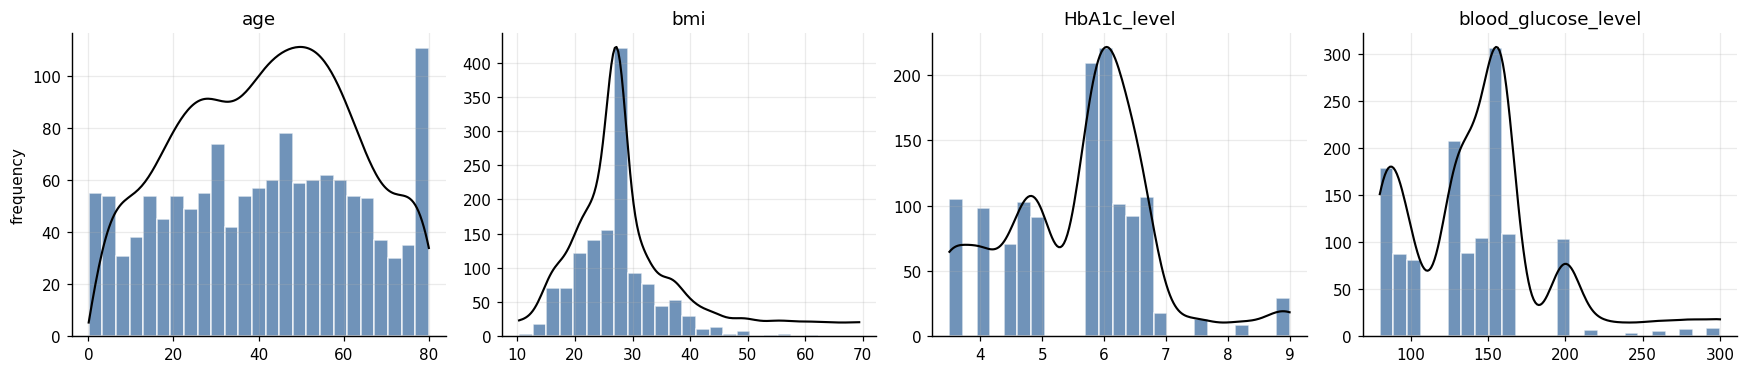

In [32]:
fig, ax = plt.subplots(1, len(NUM), figsize=(4*len(NUM), 3.5))

for j, c in enumerate(NUM):
    x = df[c].dropna()

    # Histogram
    ax[j].hist(
        x,
        bins=25,
        color="#4C78A8",
        edgecolor="white",
        alpha=0.8
    )

    # KDE
    xs = np.linspace(x.min(), x.max(), 200)
    ax2 = ax[j].twinx()
    ax2.plot(xs, gaussian_kde(x)(xs), color="black", lw=1.4)
    ax2.set_yticks([])

    ax[j].set_title(c)

ax[0].set_ylabel("frequency")
plt.tight_layout()
fig.savefig(f"{FIGDIR}/03_numeric_hist_kde.png",bbox_inches="tight", format="png")
plt.show()

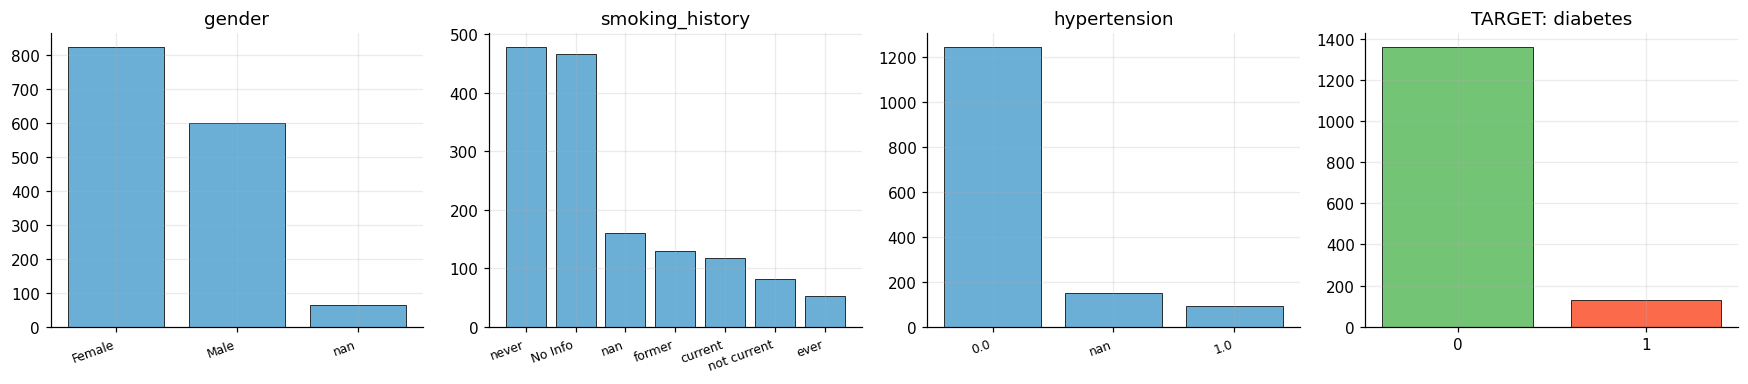

In [33]:
fig,ax=plt.subplots(1,4,figsize=(16,3.6))
for k,c in enumerate(CATc+["hypertension"]):
    vc=df[c].value_counts(dropna=False); ax[k].bar([str(i) for i in vc.index],vc.values,color="#6BAED6",edgecolor="black",lw=.5)
    ax[k].set_title(c); plt.setp(ax[k].get_xticklabels(),rotation=20,ha="right",fontsize=8)
tg=df[TARGET].value_counts(); ax[3].bar(tg.index.astype(str),tg.values,color=["#74c476","#fb6a4a"],edgecolor="black",lw=.5); ax[3].set_title(f"TARGET: {TARGET}")
plt.tight_layout(); fig.savefig(f"{FIGDIR}/04_categorical_target.png",bbox_inches="tight", format="png"); plt.show()

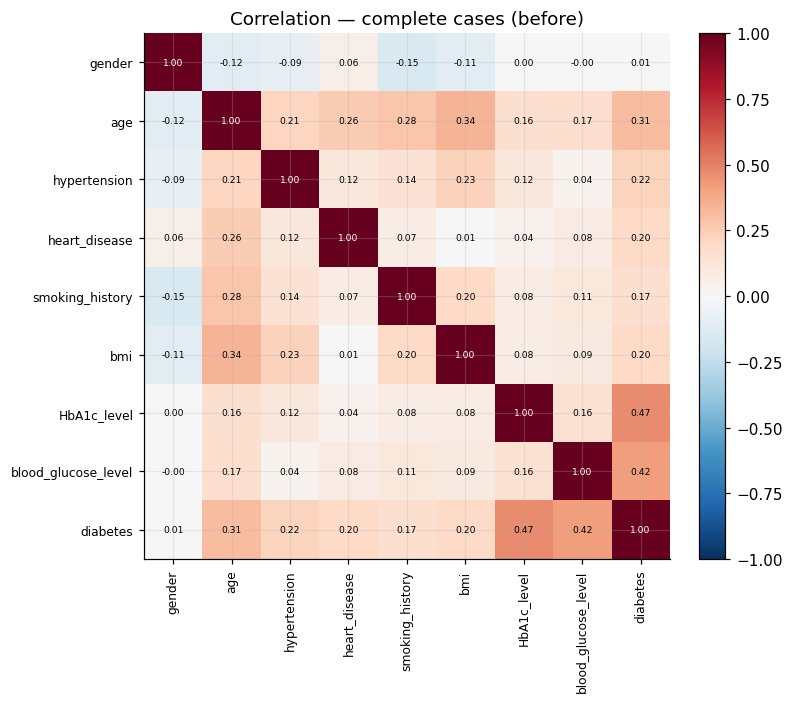

In [34]:
def heatmap(corr,title,ax):
    im=ax.imshow(corr.values,cmap="RdBu_r",vmin=-1,vmax=1)
    ax.set_xticks(range(len(corr)))
    ax.set_xticklabels(corr.columns,rotation=90,fontsize=8)
    ax.set_yticks(range(len(corr)))
    ax.set_yticklabels(corr.columns,fontsize=8)
    for i in range(len(corr)):
        for j in range(len(corr)): ax.text(j,i,f"{corr.values[i,j]:.2f}",ha="center",va="center",fontsize=6,color="white" if abs(corr.values[i,j])>.5 else "black")
    ax.set_title(title); return im
corr_before=enc.dropna().corr()
fig,ax=plt.subplots(figsize=(8,6.5))
im=heatmap(corr_before,"Correlation \u2014 complete cases (before)",ax)
fig.colorbar(im,fraction=0.046,pad=0.04)
plt.tight_layout()
fig.savefig(f"{FIGDIR}/05_correlation_before.png",bbox_inches="tight", format="png")
plt.show()

## 3 · The technique — per-column CV selection

In [35]:
SC=lambda m: make_pipeline(StandardScaler(), m)
def regressors():
  return {"Linear":SC(LinearRegression()),
      "BayesianRidge":SC(BayesianRidge()),
      "RandomForest":RandomForestRegressor(100,random_state=42),
      "AdaBoost":AdaBoostRegressor(random_state=42),
      "XGBoost":XGBRegressor(random_state=42),
      "CatBoost":CatBoostRegressor(random_state=42,verbose=0),
      "NeuralNet":SC(MLPRegressor((64,),max_iter=500,random_state=42))}
def classifiers():
  return {"Mode":DummyClassifier(strategy="most_frequent"),
      "Logistic":SC(LogisticRegression(max_iter=1000)),
      "DecisionTree":DecisionTreeClassifier(max_depth=6,random_state=42),
      "RandomForest":RandomForestClassifier(100,random_state=42),
      "AdaBoost":AdaBoostClassifier(random_state=42),
      "XGBoost":XGBClassifier(random_state=42,eval_metric="logloss"),
      "CatBoost":CatBoostClassifier(random_state=42,verbose=0),
      "NeuralNet":SC(MLPClassifier((64,),max_iter=500,random_state=42))}

def leaderboard_numeric(X,y,k=5):
  cv=KFold(min(k,len(y)),shuffle=True,random_state=42);
  rows=[]
  for nm,est in regressors().items():
      mse=[];
      mae=[];
      r2=[]
      for tr,te in cv.split(X):
        try:
          est.fit(X[tr],y[tr]);
          p=est.predict(X[te]);
          mse.append(mean_squared_error(y[te],p));
          mae.append(mean_absolute_error(y[te],p));
          r2.append(r2_score(y[te],p))
        except Exception: mse.append(np.nan)
      rows.append(dict(technique=nm,MSE=np.nanmean(mse),RMSE=np.sqrt(np.nanmean(mse)),MAE=np.nanmean(mae),R2=np.nanmean(r2)))
  return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

def leaderboard_categorical(X,y,k=5):
  k=max(2,min(k,int(np.min(np.bincount(y.astype(int))))));
  cv=StratifiedKFold(k,shuffle=True,random_state=42); rows=[]
  for nm,est in classifiers().items():
      acc=[]; pr=[]; rc=[]; f1=[]
      for tr,te in cv.split(X,y):
        try:
          est.fit(X[tr],y[tr]);
          p=est.predict(X[te]);
          acc.append(accuracy_score(y[te],p));
          pr.append(precision_score(y[te],p,average="macro",zero_division=0));
          rc.append(recall_score(y[te],p,average="macro",zero_division=0));
          f1.append(f1_score(y[te],p,average="macro",zero_division=0))
        except Exception: acc.append(np.nan)
      rows.append(dict(technique=nm,Accuracy=np.nanmean(acc),Precision=np.nanmean(pr),Recall=np.nanmean(rc),F1=np.nanmean(f1)))
  return pd.DataFrame(rows).sort_values("F1",ascending=False).reset_index(drop=True)

complete=enc.dropna().reset_index(drop=True)
leaderboards={};
chosen={}

for col in [c for c in enc.columns if enc[c].isna().any()]:
  feats=[c for c in enc.columns if c!=col];
  X=complete[feats].values
  if col in CATEGORICAL:
      lb=leaderboard_categorical(X,complete[col].values.astype(int));
      chosen[col]=("categorical",lb.iloc[0]["technique"],lb.iloc[0]["F1"])
  else:
      lb=leaderboard_numeric(X,complete[col].values);
      chosen[col]=("numeric",lb.iloc[0]["technique"],lb.iloc[0]["RMSE"])
  leaderboards[col]=lb

print("Selected per column:")
for c,(t,n,s) in chosen.items():
  print(f"  {c:<22} [{t:<11}] {n:<13} ({'F1' if t=='categorical' else 'RMSE'}={s:.3f})")


Selected per column:
  gender                 [categorical] Logistic      (F1=0.540)
  age                    [numeric    ] AdaBoost      (RMSE=20.297)
  hypertension           [categorical] AdaBoost      (F1=0.592)
  heart_disease          [categorical] NeuralNet     (F1=0.528)
  smoking_history        [categorical] XGBoost       (F1=0.227)
  bmi                    [numeric    ] BayesianRidge (RMSE=6.265)
  HbA1c_level            [numeric    ] Linear        (RMSE=1.022)
  blood_glucose_level    [numeric    ] Linear        (RMSE=37.193)


In [36]:
# metric tables
num_tbl=pd.DataFrame([dict(column=c,best=chosen[c][1],**leaderboards[c].iloc[0][["MSE","RMSE","MAE","R2"]]) for c in chosen if chosen[c][0]=="numeric"])
cat_tbl=pd.DataFrame([dict(column=c,best=chosen[c][1],**leaderboards[c].iloc[0][["Accuracy","Precision","Recall","F1"]]) for c in chosen if chosen[c][0]=="categorical"])
num_tbl.round(3).to_csv(f"{FIGDIR}/table_numeric_selection.csv",index=False)
cat_tbl.round(3).to_csv(f"{FIGDIR}/table_categorical_selection.csv",index=False)
print("NUMERIC:"); display(num_tbl.round(3)); print("CATEGORICAL:"); display(cat_tbl.round(3))

NUMERIC:


,column,best,MSE,RMSE,MAE,R2
0,age,AdaBoost,411.949,20.297,16.451,0.251
1,bmi,BayesianRidge,39.253,6.265,4.623,0.130
2,HbA1c_level,Linear,1.044,1.022,0.878,0.186
3,blood_glucose_level,Linear,1383.309,37.193,30.177,0.096


CATEGORICAL:


,column,best,Accuracy,Precision,Recall,F1
0,gender,Logistic,0.591,0.566,0.554,0.540
1,hypertension,AdaBoost,0.929,0.668,0.574,0.592
2,heart_disease,NeuralNet,0.953,0.581,0.520,0.528
3,smoking_history,XGBoost,0.453,0.241,0.231,0.227


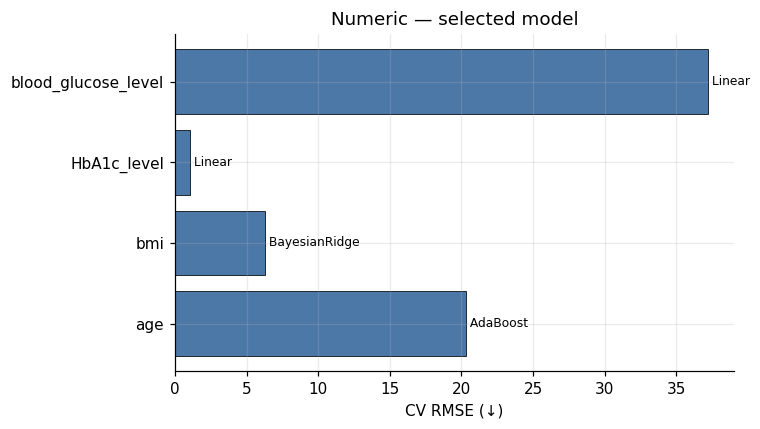

In [37]:

# NUMERIC PLOT
nsel = [(c, chosen[c][1], chosen[c][2]) for c in chosen if chosen[c][0] == "numeric"]

if nsel:
    cols, names, sc = zip(*nsel)

    fig1, ax1 = plt.subplots(figsize=(7, 4))

    ax1.barh(range(len(cols)), sc, color="#4C78A8", edgecolor="black", lw=0.5)
    ax1.set_yticks(range(len(cols)))
    ax1.set_yticklabels(cols)

    for i, (n, s) in enumerate(zip(names, sc)):
        ax1.text(s, i, f" {n}", va="center", fontsize=8)

    ax1.set_xlabel("CV RMSE (↓)")
    ax1.set_title("Numeric \u2014 selected model")

    plt.tight_layout()
    fig1.savefig(f"{FIGDIR}/06_numeric_selected.png",bbox_inches="tight", format="png")
    plt.show()

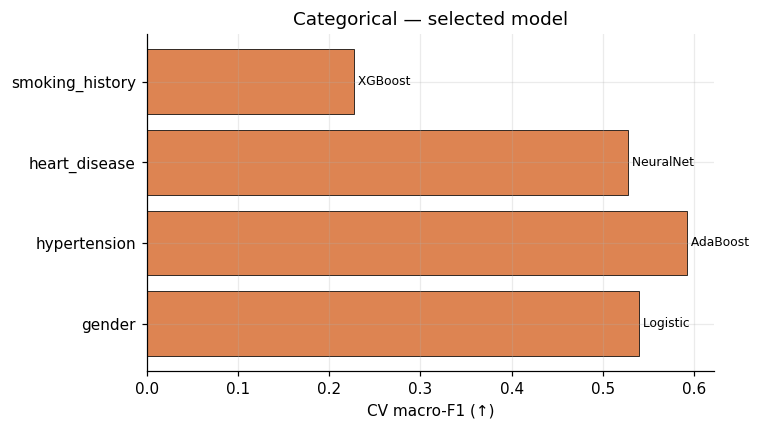

In [38]:
# CATEGORICAL PLOT
csel = [(c, chosen[c][1], chosen[c][2]) for c in chosen if chosen[c][0] == "categorical"]

if csel:
    cols, names, sc = zip(*csel)

    fig2, ax2 = plt.subplots(figsize=(7, 4))

    ax2.barh(range(len(cols)), sc, color="#DD8452", edgecolor="black", lw=0.5)
    ax2.set_yticks(range(len(cols)))
    ax2.set_yticklabels(cols)

    for i, (n, s) in enumerate(zip(names, sc)):
        ax2.text(s, i, f" {n}", va="center", fontsize=8)

    ax2.set_xlabel("CV macro-F1 (\u2191)")
    ax2.set_title("Categorical \u2014 selected model")

    plt.tight_layout()
    fig2.savefig(f"{FIGDIR}/07_categorical_selected.png",bbox_inches="tight", format="png")
    plt.show()

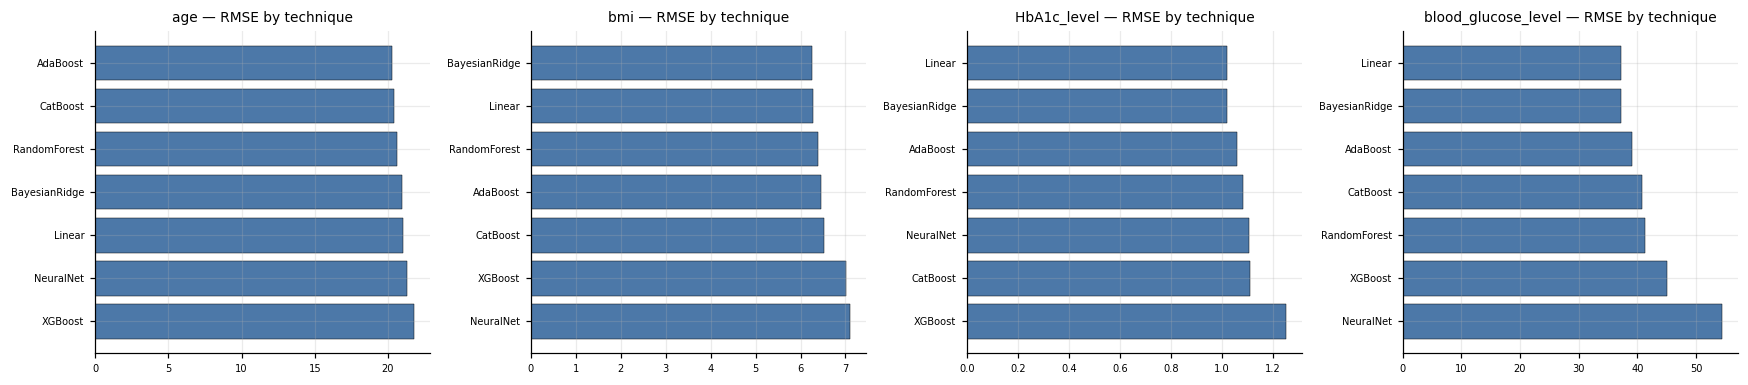

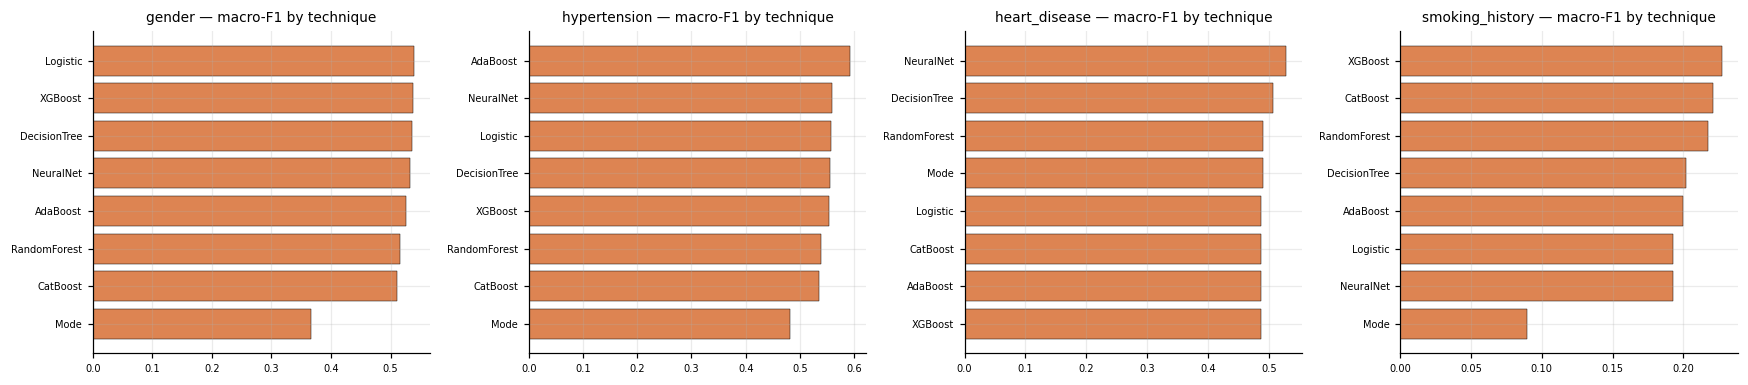

In [39]:
# per-column (numeric RMSE, categorical F1 across all techniques)
numcols=[c for c in chosen if chosen[c][0]=="numeric"]
catcols=[c for c in chosen if chosen[c][0]=="categorical"]

fig,ax=plt.subplots(1,len(numcols),figsize=(4*len(numcols),3.6),squeeze=False)
for j,c in enumerate(numcols):
    lb=leaderboards[c].sort_values("RMSE")
    ax[0,j].barh(lb.technique,lb.RMSE,color="#4C78A8",edgecolor="black",lw=.3)
    ax[0,j].invert_yaxis()
    ax[0,j].set_title(f"{c} \u2014 RMSE by technique",fontsize=9)
    ax[0,j].tick_params(labelsize=6.5)
plt.tight_layout()
fig.savefig(f"{FIGDIR}/08_leaderboards_numeric.png",bbox_inches="tight", format="png")
plt.show()

fig,ax=plt.subplots(1,len(catcols),figsize=(4*len(catcols),3.6),squeeze=False)
for j,c in enumerate(catcols):
    lb=leaderboards[c].sort_values("F1",ascending=False); ax[0,j].barh(lb.technique,lb.F1,color="#DD8452",edgecolor="black",lw=.3)
    ax[0,j].invert_yaxis()
    ax[0,j].set_title(f"{c} \u2014 macro-F1 by technique",fontsize=9)
    ax[0,j].tick_params(labelsize=6.5)
plt.tight_layout()
fig.savefig(f"{FIGDIR}/09_leaderboards_categorical.png",bbox_inches="tight", format="png")
plt.show()

## 4 · Impute the dataset

In [40]:
scaffold=enc.copy()
for c in enc.columns: scaffold[c]=scaffold[c].fillna(scaffold[c].mode().iloc[0] if c in CATEGORICAL else scaffold[c].mean())
imp_enc=enc.copy()
for col,(typ,name,_) in chosen.items():
    feats=[c for c in enc.columns if c!=col]
    est=(classifiers() if typ=="categorical" else regressors())[name]
    y=complete[col].values.astype(int) if typ=="categorical" else complete[col].values
    est.fit(complete[feats].values,y)
    mrows=enc[col].isna().values;
    imp_enc.loc[mrows,col]=est.predict(scaffold.loc[mrows,feats].values)
imp=df.copy()
for c in NUM: imp[c]=imp_enc[c].values
for c in BIN: imp[c]=imp_enc[c].round().clip(0,1).astype(int)
for c in CATc:
    inv={i:v for v,i in maps[c].items()};
    valid=np.array(sorted(inv)); imp[c]=imp_enc[c].apply(lambda v: inv[valid[np.argmin(np.abs(valid-v))]])
imp.to_csv("diabetes_dataset_imputed.csv",index=False);
print("missing after:",int(imp.isna().sum().sum()))

missing after: 0


## 5 · Imputation quality

In [44]:
def impute_eval(E):   # robust per-column imputation for masked frames
    cols=list(E.columns)
    mask=E.isna()
    sc=E.copy()
    for c in cols: sc[c]=sc[c].fillna(sc[c].mode().iloc[0] if c in CATEGORICAL else sc[c].mean())
    out=E.copy()
    for col in [c for c in cols if mask[c].any()]:
        feats=[c for c in cols if c!=col]
        obs=~mask[col].values; Xtr=sc.loc[obs,feats].values
        if col in CATEGORICAL:
            y=E.loc[obs,col].values.astype(int)
            if len(np.unique(y))<2 or len(y)<12: out.loc[mask[col].values,col]=pd.Series(y).mode().iloc[0]; continue
            lb=leaderboard_categorical(Xtr,y)
            est=classifiers()[lb.iloc[0]["technique"]]
            est.fit(Xtr,y)
        else:
            y=E.loc[obs,col].values
            if len(y)<12: out.loc[mask[col].values,col]=float(np.mean(y)); continue
            lb=leaderboard_numeric(Xtr,y); est=regressors()[lb.iloc[0]["technique"]]
            est.fit(Xtr,y)
        out.loc[mask[col].values,col]=est.predict(sc.loc[mask[col].values,feats].values).ravel()
    return out

gt=enc[FEATURES].dropna().reset_index(drop=True);
rng=np.random.default_rng(0)
mask=pd.DataFrame(False,index=gt.index,columns=gt.columns)
for c in gt.columns:
    idx=rng.choice(gt.index,int(0.2*len(gt)),replace=False)
    mask.loc[idx,c]=True
rec=impute_eval(gt.mask(mask))

rows=[]
for c in NUM:
    m=mask[c].values
    rows.append(dict(column=c,type="numeric",RMSE=np.sqrt(mean_squared_error(gt[c][m],rec[c][m])),MAE=mean_absolute_error(gt[c][m],rec[c][m]),R2=r2_score(gt[c][m],rec[c][m])))
for c in CAT:
    m=mask[c].values; t=gt[c][m].round().astype(int)
    p=rec[c][m].round().astype(int)
    rows.append(dict(column=c,type="categorical",Accuracy=accuracy_score(t,p),Precision=precision_score(t,p,average="macro",zero_division=0),Recall=recall_score(t,p,average="macro",zero_division=0),F1=f1_score(t,p,average="macro",zero_division=0)))
quality=pd.DataFrame(rows)
quality.round(3).to_csv(f"{FIGDIR}/table_imputation_quality.csv",index=False)
quality.round(3)

,column,type,RMSE,MAE,R2,Accuracy,Precision,Recall,F1
0,age,numeric,20.910,17.183,0.110,NaN,NaN,NaN,NaN
1,bmi,numeric,7.436,5.264,0.067,NaN,NaN,NaN,NaN
2,HbA1c_level,numeric,1.112,0.862,0.022,NaN,NaN,NaN,NaN
3,blood_glucose_level,numeric,40.442,29.807,-0.002,NaN,NaN,NaN,NaN
4,gender,categorical,NaN,NaN,NaN,0.656,0.675,0.573,0.541
5,smoking_history,categorical,NaN,NaN,NaN,0.389,0.160,0.174,0.166
6,hypertension,categorical,NaN,NaN,NaN,0.956,0.478,0.500,0.489
7,heart_disease,categorical,NaN,NaN,NaN,0.967,0.483,0.500,0.492


## 6 · Before vs. after the imputation

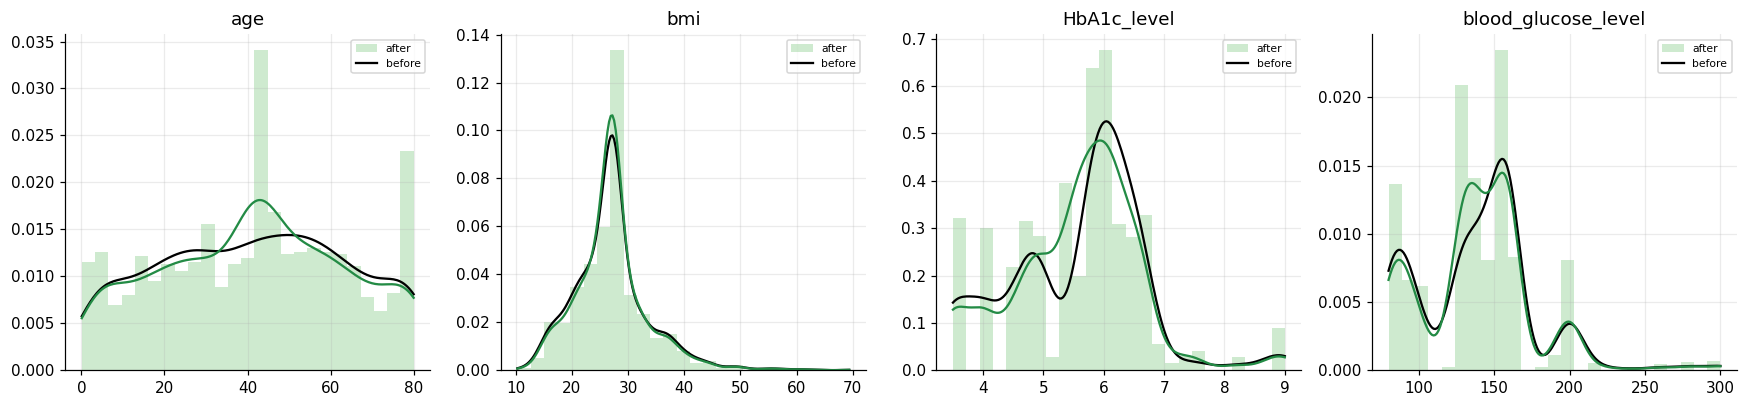

In [45]:
fig,ax=plt.subplots(1,len(NUM),figsize=(4*len(NUM),3.8))
for j,c in enumerate(NUM):
    before=df[c].dropna(); after=imp[c]
    xs=np.linspace(after.min(),after.max(),200)
    ax[j].hist(after,bins=25,density=True,alpha=.35,color="#74c476",label="after")
    ax[j].plot(xs,gaussian_kde(before)(xs),color="black",lw=1.5,label="before")
    ax[j].plot(xs,gaussian_kde(after)(xs),color="#238b45",lw=1.5)
    ax[j].set_title(c)
    ax[j].legend(fontsize=7)
plt.tight_layout()
fig.savefig(f"{FIGDIR}/10_distribution_before_after.png",bbox_inches="tight", format="png")
plt.show()

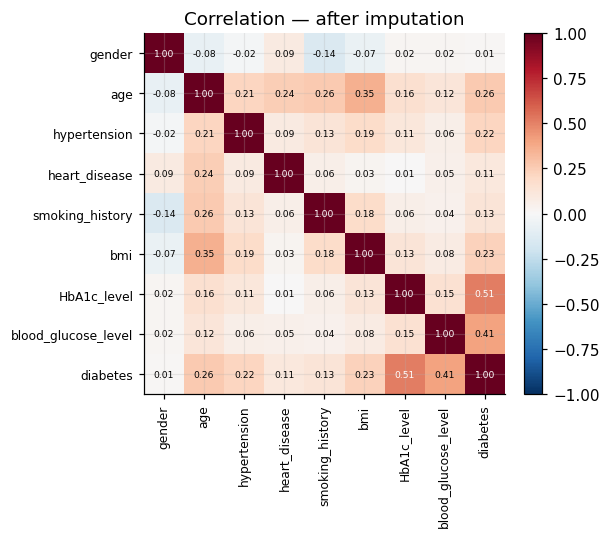

In [46]:
corr_after = encode(imp).astype(float).corr()

fig, ax = plt.subplots(figsize=(6,5))

im0 = heatmap(
    corr_after,
    "Correlation \u2014 after imputation",
    ax
)

fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
fig.savefig(f"{FIGDIR}/11_corr_after_imputation.png",bbox_inches="tight", format="png")
plt.show()

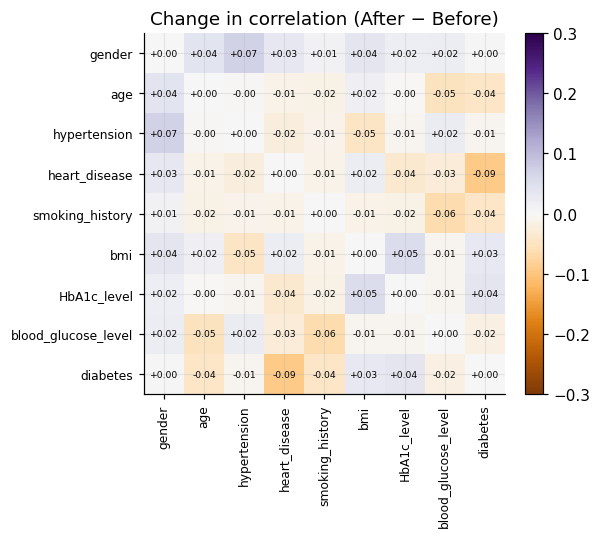

In [47]:
delta = corr_after - corr_before

fig, ax = plt.subplots(figsize=(6,5))

im1 = ax.imshow(delta.values, cmap="PuOr", vmin=-0.3, vmax=0.3)

ax.set_xticks(range(len(delta)))
ax.set_xticklabels(delta.columns, rotation=90, fontsize=8)

ax.set_yticks(range(len(delta)))
ax.set_yticklabels(delta.columns, fontsize=8)

for i in range(len(delta)):
    for j in range(len(delta)):
        ax.text(
            j, i,
            f"{delta.values[i,j]:+.2f}",
            ha="center",
            va="center",
            fontsize=6
        )

ax.set_title("Change in correlation (After \u2212 Before)")

fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
fig.savefig(f"{FIGDIR}/12_corr_change.png",bbox_inches="tight", format="png")
plt.show()

## 8 · Prediction on the imputed data

In [48]:
E=encode(imp)
X=E[FEATURES].values
y=E[TARGET].astype(int).values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

models={
    "Random Forest": RandomForestClassifier(100,random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric="logloss", use_label_encoder=False
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100, random_state=42, verbose=0
    ),
}

rows={}
for nm,mdl in models.items():
    mdl.fit(Xtr,ytr); pb=mdl.predict_proba(Xte)[:,1]; pr=(pb>=.5).astype(int)
    rows[nm]=dict(RMSE=np.sqrt(mean_squared_error(yte,pb)),Accuracy=accuracy_score(yte,pr),Precision=precision_score(yte,pr,zero_division=0),
                  Recall=recall_score(yte,pr,zero_division=0),F1=f1_score(yte,pr,zero_division=0),ROC_AUC=roc_auc_score(yte,pb))

metrics=pd.DataFrame(rows).T.round(3); metrics.to_csv(f"{FIGDIR}/table_downstream_metrics.csv"); metrics

,RMSE,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.117,0.983,1.00,0.808,0.894,0.998
XGBoost,0.156,0.970,0.87,0.769,0.816,0.982
CatBoost,0.119,0.983,1.00,0.808,0.894,0.995


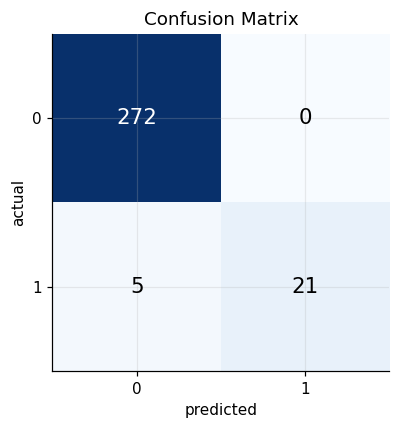

In [49]:
cm = confusion_matrix(yte, pr)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=14,
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Confusion Matrix")

plt.tight_layout()
fig.savefig(f"{FIGDIR}/13_confusion_matrix.png",bbox_inches="tight", format="png")
plt.show()

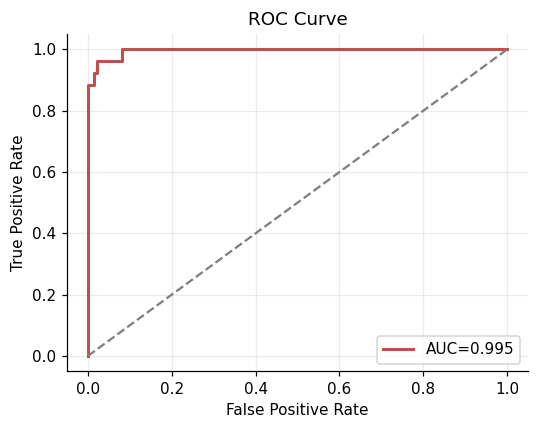

In [50]:
fpr, tpr, _ = roc_curve(yte, pb)
auc = roc_auc_score(yte, pb)

fig, ax = plt.subplots(figsize=(5,4))

ax.plot(fpr, tpr, color="#C0504D", lw=2, label=f"AUC={auc:.3f}")
ax.plot([0,1], [0,1], "--", color="gray")

ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
fig.savefig(f"{FIGDIR}/14_roc_curve.png",bbox_inches="tight", format="png")
plt.show()